In [ ]:
!pip install gymnasium torch torchvision --quiet

In [ ]:
import math
import random
import collections
from typing import Tuple

import numpy as np
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Env

In [ ]:
class RouletteEnv(gym.Env):
    metadata = {"render_modes": ["human"], "render_fps": 4}


    def __init__(self, history_len: int = 5, seed: int = None):
        super().__init__()
        self.history_len = history_len
        # observation: last history_len outcomes: -1 (black), 0 (green/zero), +1 (red)
        self.observation_space = spaces.Box(low=-1.0, high=1.0, shape=(history_len,), dtype=np.float32)
        # actions: bet red or bet black
        self.action_space = spaces.Discrete(2)
        # roulette mapping: we'll define set of red numbers
        self._reds = {1,3,5,7,9,12,14,16,18,19,21,23,25,27,30,32,34,36}
        self._rng = np.random.RandomState(seed)
        self.history = [0]*history_len


    def step(self, action: int) -> Tuple[np.ndarray, float, bool, bool, dict]:
        # spin
        pocket = int(self._rng.randint(0,37))
        if pocket == 0:
            outcome = 0
        elif pocket in self._reds:
            outcome = 1
        else:
            outcome = -1
        # reward: +1 for winning bet, -1 for losing bet
        bet_on_red = (action == 0)
        win = (outcome == 1 and bet_on_red) or (outcome == -1 and not bet_on_red)
        reward = 1.0 if win else -1.0
        # update history
        self.history.pop(0)
        self.history.append(outcome)
        obs = np.array(self.history, dtype=np.float32)
        done = False # continuing task (we'll manage episodes externally)
        truncated = False
        info = {"pocket": pocket, "outcome": outcome}
        return obs, reward, done, truncated, info


    def reset(self, seed: int = None, options: dict = None) -> Tuple[np.ndarray, dict]:
        if seed is not None:
            self._rng = np.random.RandomState(seed)
            self.history = [0]*self.history_len
        return np.array(self.history, dtype=np.float32), {}


    def render(self, mode="human"):
        print("History:", self.history)

# Reply Buffer

In [ ]:
class ReplayBuffer:
    def __init__(self, capacity:int):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size:int):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done

    def __len__(self):
        return len(self.buffer)

# DQN Implementation

In [ ]:
class DQN(nn.Module):
    def __init__(self, obs_size:int, n_actions:int, hidden:int=64):
        super().__init__()
        self.net = nn.Sequential(
        nn.Linear(obs_size, hidden),
        nn.ReLU(),
        nn.Linear(hidden, hidden),
        nn.ReLU(),
        nn.Linear(hidden, n_actions)
        )

    def forward(self, x):
        return self.net(x)

# Train

In [ ]:
def train_dqn(
    env,
    episodes=2000,
    buffer_size=10000,
    batch_size=64,
    gamma=0.99,
    lr=1e-3,
    sync_freq=100,
    start_learning=500,
    eps_start=1.0,
    eps_final=0.02,
    eps_decay=1000,
    device=None
):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    obs_size = env.observation_space.shape[0]
    n_actions = env.action_space.n

    net = DQN(obs_size, n_actions).to(device)
    target_net = DQN(obs_size, n_actions).to(device)
    target_net.load_state_dict(net.state_dict())

    optimizer = optim.Adam(net.parameters(), lr=lr)
    rb = ReplayBuffer(buffer_size)

    total_rewards = []
    losses = []
    step_idx = 0

    state, _ = env.reset()

    for ep in range(episodes):
        state, _ = env.reset()
        ep_reward = 0.0
        # we'll run a fixed number of steps per episode (e.g., 1 step) to emulate independent bets
        # but to allow learning we perform e.g. 10 bets per episode
        steps_per_episode = 10
        for t in range(steps_per_episode):
            step_idx += 1
            eps_threshold = eps_final + (eps_start - eps_final) * math.exp(-1.0 * step_idx / eps_decay)
            if random.random() < eps_threshold:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    s_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                    q_vals = net(s_t)
                    action = int(q_vals.argmax().item())


            next_state, reward, done, truncated, info = env.step(action)
            rb.push(state, action, reward, next_state, False)
            state = next_state
            ep_reward += reward

            if len(rb) >= start_learning:
                states, actions, rewards, next_states, dones = rb.sample(batch_size)
                states_v = torch.tensor(states, dtype=torch.float32, device=device)
                actions_v = torch.tensor(actions, dtype=torch.int64, device=device)
                rewards_v = torch.tensor(rewards, dtype=torch.float32, device=device)
                next_states_v = torch.tensor(next_states, dtype=torch.float32, device=device)
                dones_v = torch.tensor(dones, dtype=torch.float32, device=device)

                q_vals = net(states_v).gather(1, actions_v.unsqueeze(-1)).squeeze(-1)
                with torch.no_grad():
                    q_next = target_net(next_states_v).max(1)[0]
                    q_target = rewards_v + gamma * q_next * (1 - dones_v)

                loss = F.mse_loss(q_vals, q_target)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                losses.append(loss.item())

            if step_idx % sync_freq == 0:
                target_net.load_state_dict(net.state_dict())

        total_rewards.append(ep_reward)

        if (ep+1) % 100 == 0:
            avg_r = np.mean(total_rewards[-100:])
            avg_loss = np.mean(losses[-100:]) if losses else 0.0
            print(f"Episode {ep+1}\tAvg reward (last100): {avg_r:.3f}\tAvg loss: {avg_loss:.4f}\tEPS: {eps_threshold:.3f}")


    return net, target_net, total_rewards, losses

# Main

Episode 100	Avg reward (last100): 0.000	Avg loss: 0.9548	EPS: 0.381
Episode 200	Avg reward (last100): 0.160	Avg loss: 0.9930	EPS: 0.153
Episode 300	Avg reward (last100): -0.220	Avg loss: 0.9737	EPS: 0.069
Episode 400	Avg reward (last100): -0.340	Avg loss: 0.9665	EPS: 0.038
Episode 500	Avg reward (last100): -0.300	Avg loss: 0.9814	EPS: 0.027
Episode 600	Avg reward (last100): -0.720	Avg loss: 1.0889	EPS: 0.022
Episode 700	Avg reward (last100): -0.040	Avg loss: 1.1012	EPS: 0.021
Episode 800	Avg reward (last100): 0.160	Avg loss: 1.0209	EPS: 0.020
Episode 900	Avg reward (last100): -0.020	Avg loss: 1.0423	EPS: 0.020
Episode 1000	Avg reward (last100): -0.320	Avg loss: 1.0675	EPS: 0.020
Episode 1100	Avg reward (last100): -0.720	Avg loss: 0.9874	EPS: 0.020
Episode 1200	Avg reward (last100): 0.320	Avg loss: 1.0137	EPS: 0.020


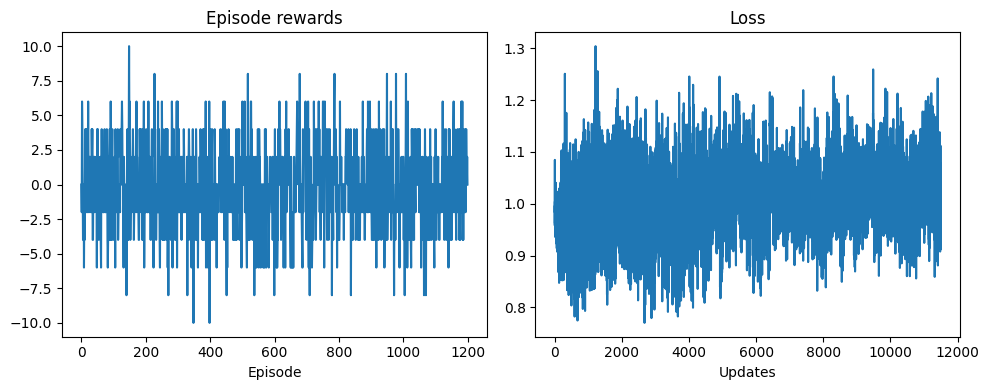

Greedy policy win rate over 1000 trials: 0.505 (random baseline ~18/37=0.486)


In [ ]:
if __name__ == "__main__":
    env = RouletteEnv(history_len=5, seed=42)
    net, target_net, rewards, losses = train_dqn(env, episodes=1200, start_learning=500, buffer_size=5000)

    # plot results
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.title('Episode rewards')
    plt.plot(rewards)
    plt.xlabel('Episode')
    plt.subplot(1,2,2)
    plt.title('Loss')
    plt.plot(losses)
    plt.xlabel('Updates')
    plt.tight_layout()
    plt.show()

    net = net.to(device)

    # Evaluate greedy policy
    state, _ = env.reset()
    wins = 0
    trials = 1000
    for _ in range(trials):
        with torch.no_grad():
            s_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            action = int(net(s_t).argmax().item())

        next_state, reward, done, truncated, info = env.step(action)

        if reward > 0:
            wins += 1
        state = next_state

    print(f"Greedy policy win rate over {trials} trials: {wins/trials:.3f} (random baseline ~18/37=0.486)")